# Importing Requirements

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

if not os.path.exists('../plots'):
    os.makedirs('../plots')
if not os.path.exists('../report/tables'):
    os.makedirs('../report/tables')


# Constants and Data Input

In [2]:
# Constants
h = 6.626e-34 # J s
m_e = 9.109e-31 # kg
e = 1.602e-19 # C
L = 0.0675 # m

# Read data
df = pd.read_csv('../DATA/data.csv')
print(df)


     V    R1    R2
0  3.5  0.65  1.07
1  4.5  0.60  1.06
2  5.5  0.50  0.87


# Data Analysis

In [3]:
# Convert units
V_kV = df['V'].values
V_V = V_kV * 1000
R1_cm = df['R1'].values
R2_cm = df['R2'].values
R1_m = R1_cm / 100
R2_m = R2_cm / 100

# Calculate d10 and d11 for each row
const_factor = (L * h) / np.sqrt(2 * m_e * e)
d10 = const_factor / (R1_m * np.sqrt(V_V))
d11 = const_factor / (R2_m * np.sqrt(V_V))

# Convert to nm
d10_nm = d10 * 1e9
d11_nm = d11 * 1e9

df_out = df.copy()
df_out['d10 (nm)'] = np.round(d10_nm, 3)
df_out['d11 (nm)'] = np.round(d11_nm, 3)

print("Calculated individual d values (nm):")
print(df_out)

# Format for LaTeX export
df_tex = pd.DataFrame({
    'V': V_kV,
    'R1': R1_cm,
    'R2': R2_cm,
    'd10': df_out['d10 (nm)'],
    'd11': df_out['d11 (nm)']
})
df_tex.to_csv('../report/tables/table1.csv', index=False)


Calculated individual d values (nm):
     V    R1    R2  d10 (nm)  d11 (nm)
0  3.5  0.65  1.07     0.215     0.131
1  4.5  0.60  1.06     0.206     0.116
2  5.5  0.50  0.87     0.223     0.128


# Plots and Linear Regression

Zero-int slope 1: 7.7341e-01
Zero-int slope 2: 1.3228e+00

From graph slope:
d10 = 0.214 nm (Theoretical: 0.213 nm)
d11 = 0.125 nm (Theoretical: 0.123 nm)


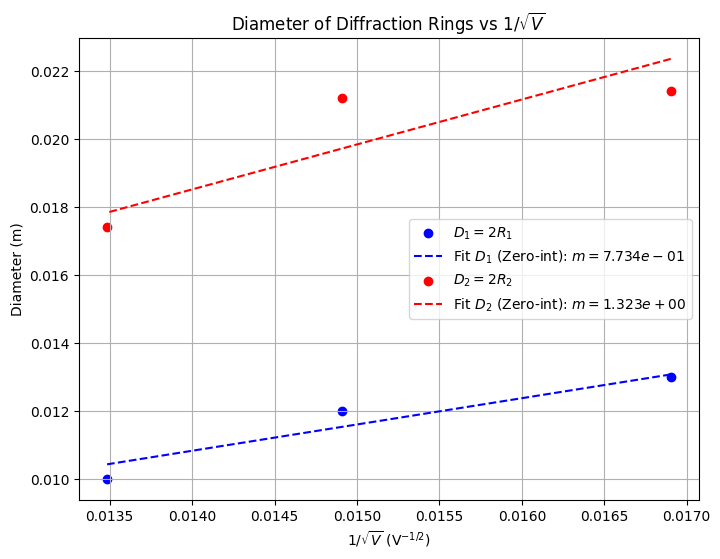

In [4]:
# Plot D vs 1/sqrt(V)
D1_m = 2 * R1_m
D2_m = 2 * R2_m
x = 1.0 / np.sqrt(V_V)

slope1_zero = np.sum(x * D1_m) / np.sum(x**2)
slope2_zero = np.sum(x * D2_m) / np.sum(x**2)

print(f"Zero-int slope 1: {slope1_zero:.4e}")
print(f"Zero-int slope 2: {slope2_zero:.4e}")

d10_graph = (2 * L * h) / (slope1_zero * np.sqrt(2 * m_e * e))
d11_graph = (2 * L * h) / (slope2_zero * np.sqrt(2 * m_e * e))

print(f"\nFrom graph slope:")
print(f"d10 = {d10_graph*1e9:.3f} nm (Theoretical: 0.213 nm)")
print(f"d11 = {d11_graph*1e9:.3f} nm (Theoretical: 0.123 nm)")

with open('../report/tables/graph_results.tex', 'w') as f:
    f.write(f"d_{{10}} = {d10_graph*1e9:.3f} \,\mathrm{{nm}} \\\n")
    f.write(f"d_{{11}} = {d11_graph*1e9:.3f} \,\mathrm{{nm}}\n")

plt.figure(figsize=(8,6))
plt.scatter(x, D1_m, color='blue', label='$D_1 = 2R_1$')
plt.plot(x, slope1_zero*x, 'b--', label=f'Fit $D_1$ (Zero-int): $m={slope1_zero:.3e}$')

plt.scatter(x, D2_m, color='red', label='$D_2 = 2R_2$')
plt.plot(x, slope2_zero*x, 'r--', label=f'Fit $D_2$ (Zero-int): $m={slope2_zero:.3e}$')

plt.xlabel(r'$1/\sqrt{V}$ (V$^{-1/2}$)')
plt.ylabel('Diameter (m)')
plt.title('Diameter of Diffraction Rings vs $1/\sqrt{V}$')
plt.legend()
plt.grid(True)
plt.savefig('../plots/diameter_vs_voltage.png', dpi=300)
plt.show()
